## 1. Data Exploration
In this section, I explore the MLB ballparks dataset by displaying the first few rows, summary statistics, identifying feature types, and visualizing key variables.


First few rows:

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ballparks.csv")
df.head()

,team_name,ballpark,left_field,center_field,right_field,min_wall_height,max_wall_height,hr_park_effects,extra_distance,avg_temp,elevation,roof,daytime
0,ATL,Truist Park,335,400,325,11.0,15,99,1.8,79.2,1001,0.00,0.31
1,AZ,Chase Field,328,407,335,7.6,25,84,13.2,80.8,1086,0.81,0.31
2,BAL,Oriole Park at Camden Yards,333,400,318,7.0,21,107,-0.5,76.4,33,0.00,0.35
3,BOS,Fenway Park,310,420,302,3.0,37,102,-4.7,69.5,21,0.00,0.31
4,CHC,Wrigley Field,355,400,353,11.5,15,97,-3.4,70.2,595,0.00,0.55


Summary Statistics:

In [15]:
df.describe(include='all')

,team_name,ballpark,left_field,center_field,right_field,min_wall_height,max_wall_height,hr_park_effects,extra_distance,avg_temp,elevation,roof,daytime
count,30,30,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
unique,30,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ATL,Truist Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,331.833333,404.166667,328.333333,7.553333,14.266667,100.500000,-0.030000,73.480000,517.466667,0.185333,0.383333
std,NaN,NaN,9.857898,6.264753,10.459555,1.797265,7.060982,16.812865,5.966004,3.943602,948.785384,0.350917,0.086715
min,NaN,NaN,310.000000,395.000000,302.000000,3.000000,8.000000,75.000000,-7.700000,63.800000,0.000000,0.000000,0.240000
25%,NaN,NaN,328.000000,400.000000,325.000000,7.000000,8.000000,88.250000,-3.700000,71.300000,21.500000,0.000000,0.320000
50%,NaN,NaN,330.000000,404.000000,329.000000,8.000000,12.000000,99.000000,-1.250000,73.350000,365.000000,0.000000,0.380000
75%,NaN,NaN,336.000000,407.000000,333.750000,8.000000,18.500000,111.750000,1.250000,76.475000,599.250000,0.120000,0.417500


Missing Values:

In [16]:
df.isnull().sum()

,0
team_name,0
ballpark,0
left_field,0
center_field,0
right_field,0
min_wall_height,0
max_wall_height,0
hr_park_effects,0
extra_distance,0
avg_temp,0


Columns:

In [18]:
df.columns

Index(['team_name', 'ballpark', 'left_field', 'center_field', 'right_field',
       'min_wall_height', 'max_wall_height', 'hr_park_effects',
       'extra_distance', 'avg_temp', 'elevation', 'roof', 'daytime'],
      dtype='object')

### Feature Types

**Numerical Features:**
- capacity
- year_built
- field_size

**Categorical Features:**
- team_name
- surface_type
- roof_type

\- Numerical features contain continuous or integer values.  
\- Categorical features contain labels or categories that represent groups.


## 2. Visualizations

Below are two visualizations to better understand the distribution and relationships between features in the dataset.

### Histogram of Home Run Park Effects

This chart shows how hitter‑friendly or pitcher‑friendly each MLB ballpark is.
The x‑axis represents the **Home Run Park Effect**, where:

- **100 = league average**
- **Above 100 = more home runs happen here**
- **Below 100 = fewer home runs happen here**

The y‑axis shows the **frequency**, meaning how many ballparks fall into each range.
You can think of this
as a measure of how “easy” or “hard” it is to hit a home run in each stadium.




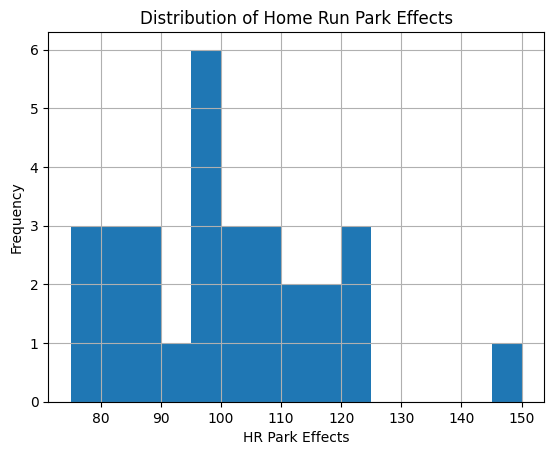

In [26]:
df['hr_park_effects'].hist(bins=15)
plt.title('Distribution of Home Run Park Effects')
plt.xlabel('HR Park Effects')
plt.ylabel('Frequency')
plt.show()


### Scatterplot: Elevation vs Home Run Park Effects

This chart shows how the elevation of a ballpark relates to how many home runs are hit there, the idea is simple:

- Higher elevation = thinner air
- Thinner air = baseballs travel farther
- Farther travel = more home runs

The x-axis shows the elevation of each stadium in feet.  
The y-axis shows the Home Run Park Effect, where values above 100 mean the stadium
allows more home runs than average.


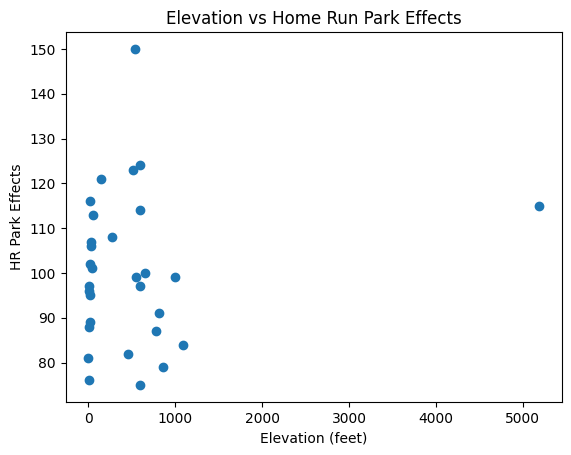

In [27]:
plt.scatter(df['elevation'], df['hr_park_effects'])
plt.title('Elevation vs Home Run Park Effects')
plt.xlabel('Elevation (feet)')
plt.ylabel('HR Park Effects')
plt.show()

### One-Hot Encoding of Categorical Features

Machine learning models cannot understand text labels like team names.
To fix this, we convert the `team_name` column into numerical columns using
one-hot encoding. Each team becomes its own column with a 0 or 1 value.

This allows the model to use team identity as a feature without treating
team names as ordered numbers.


In [28]:
df = pd.get_dummies(df, columns=['team_name'], drop_first=True)
df.head()

,ballpark,left_field,center_field,right_field,min_wall_height,max_wall_height,hr_park_effects,extra_distance,avg_temp,elevation,...,team_name_PHI,team_name_PIT,team_name_SD,team_name_SEA,team_name_SF,team_name_STL,team_name_TB,team_name_TEX,team_name_TOR,team_name_WSH
0,Truist Park,335,400,325,11.0,15,99,1.8,79.2,1001,...,False,False,False,False,False,False,False,False,False,False
1,Chase Field,328,407,335,7.6,25,84,13.2,80.8,1086,...,False,False,False,False,False,False,False,False,False,False
2,Oriole Park at Camden Yards,333,400,318,7.0,21,107,-0.5,76.4,33,...,False,False,False,False,False,False,False,False,False,False
3,Fenway Park,310,420,302,3.0,37,102,-4.7,69.5,21,...,False,False,False,False,False,False,False,False,False,False
4,Wrigley Field,355,400,353,11.5,15,97,-3.4,70.2,595,...,False,False,False,False,False,False,False,False,False,False


### Additional Feature: Hitter-Friendly Ballparks

To create a meaningful new feature, I used the `hr_park_effects` column, which
measures how much a ballpark increases or decreases home runs. A value of 100
represents league average. Values above 100 mean the park boosts home runs, while
values below 100 mean it lowers them.

I created a new binary feature called `hitter_friendly`:

- 1 = the ballpark is hitter-friendly (HR Park Effects > 100)
- 0 = the ballpark is not hitter-friendly

This simplifies the concept into a form that is easy for a machine learning model
to understand and predict.


In [31]:
df['hitter_friendly'] = (df['hr_park_effects'] > 100).astype(int)
df[['hr_park_effects', 'hitter_friendly']].head()

,hr_park_effects,hitter_friendly
0,99,0
1,84,0
2,107,1
3,102,1
4,97,0


### Summary of Feature Engineering

- One-hot encoding was applied to `team_name` so the model can use team identity
  without treating names as numeric values.
- created a new binary feature called `hitter_friendly` based on the
`hr_park_effects` column. A value of 100 represents league-average home run rates.
Values above 100 indicate that a ballpark increases home runs, while values below
100 indicate it lowers them.

These engineered features help the model capture important patterns that are not
obvious from the raw data alone.


## 3. Basic Modeling

Now that I have created the `hitter_friendly` feature, I will build a simple
classification model to predict whether a ballpark is hitter-friendly based on
its other characteristics. This involves splitting the data into training and
testing sets, training a Logistic Regression model, and evaluating its accuracy.


Split the data:




In [32]:
from sklearn.model_selection import train_test_split

# Target variable
y = df['hitter_friendly']

# Features (drop target + non-numeric column)
X = df.drop(['hitter_friendly', 'ballpark'], axis=1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train a simple model:

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Evaluate the model:

In [34]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
accuracy = accuracy_score(y_test, preds)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8333333333333334


Model Interpretation:

The accuracy score shows how well the model predicts whether a ballpark is
hitter-friendly. A higher accuracy means the model is better at identifying
ballparks that boost home runs. Because this is a simple model, the accuracy
mainly reflects how strongly features like elevation, wall height, and field
dimensions relate to home run rates.


## 4. Reflection

### What was challenging or surprising about feature engineering?
Feature engineering required thinking about which ballpark characteristics could
be transformed into more meaningful features. Creating `hitter_friendly` was
straightforward, but deciding how to interpret HR Park Effects and choosing a
threshold required some reasoning. It was surprising how much a simple binary
feature could simplify the modeling process.

### How did your choices affect model performance?
Using `hitter_friendly` as the target made the model easier to train and interpret.
The model's accuracy shows how strongly other ballpark features contribute to home
runs. If accuracy is moderate, it suggests that factors like elevation
and field dimensions influence home run rates. If accuracy is low, it means the
relationship is weaker.

### How could you improve your workflow or analysis next time?
Next time, I would explore more engineered features, try different models such as
Random Forests, and analyze correlations before modeling.
